In [2]:
# Library
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

### Polymarket EDA for Crypto

**Table of Contents**

1. Environment Setup and Data Loading

2. Data Preprocessing and Understanding

3. Analytical Plots

### 1. Environment Setup and Data Loading

In [3]:
# Run EDA starter as the base
%run eda_starter_template.py


[Memory] Initial memory usage: 153.67 MB

Loading Bitcoin data from C:\Users\19741\Desktop\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\lse-bitcoin-analytics-capstone-template\data\Coin Metrics\coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 153.67 MB
[Memory] After loading Bitcoin data: 156.95 MB (Δ 3.28 MB)
Error loading Bitcoin data: 系统找不到指定的文件。 (os error 2): ...ct Bitcoin/lse-bitcoin-analytics-capstone-template/data/Coin Metrics/coinmetrics_btc.csv (set POLARS_VERBOSE=1 to see full path)
Loading Polymarket data from C:\Users\19741\Desktop\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\lse-bitcoin-analytics-capstone-template\data\Polymarket...
[Memory] Before loading Polymarket data: 156.96 MB
[Memory] After loading Polymarket data: 156.96 MB (Δ 0.00 MB)

[Memory] Final memory usage: 156.96 MB (Total Δ: 3.29 MB)

EDA Layout Complete. Check the 'plots' directory for visualizations.


In [3]:
# Download data
%run "C:/Users/19741/Desktop/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/data/download_data.py"

--- Downloading Capstone Data ---


Retrieving folder contents


Retrieving folder 1mgd1yrowPdQ0JKtdnKBQYHpvcdyRlXcV Coin Metrics
Processing file 1IUADRKckAZVoFYIJjTt9f_la-CQmnXIN coinmetrics_btc.csv
Processing file 1KVBZIl45-DnY0EzbA6-qFZi7kvu1iH8H coinmetrics_spec.md
Retrieving folder 1f_RjuR2AVTpuJeX6jgeoKcspjUp9_lif Polymarket
Processing file 14v0AUTMO6GwQ4ItLNRI8EuxLXplvCoGt finance_politics_event_stats.parquet
Processing file 1oF4B2zvi21br9a6NFVTwjAB8mfNuLdYx finance_politics_markets.parquet
Processing file 1z4nfPZL04Rkhp82piCvqRFerKBQbrXCh finance_politics_odds_history.parquet
Processing file 1QrWoxsFnfxv7Qs1lR4j2wpTs20MqOLnk finance_politics_summary.parquet
Processing file 1K1DjGkN4fkDMRXqZekS_-vRn-WErRLsz finance_politics_tokens.parquet
Processing file 1GO00RPaS7Q2ncX0fcUHiBLyy4bZR4_Yt finance_politics_trades.parquet
Processing file 1SwimJ6dcwl8TWUR1qKWsC1pzXAb9RHTs polymarket_btc_analytics_schema.md
Retrieving folder 1SvAwcdegMzgPANM4pnuTH_9DbNEyXt8N Trilemma Bitcoin Node
Processing file 1rK39jK7QServY_ETFGKXQmXGLjYcUtER bitcoin_analytics.

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1IUADRKckAZVoFYIJjTt9f_la-CQmnXIN
To: c:\Users\19741\Desktop\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\lse-bitcoin-analytics-capstone-template\eda\tmp_capstone_data\Coin Metrics\coinmetrics_btc.csv
100%|██████████| 2.42M/2.42M [00:00<00:00, 20.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KVBZIl45-DnY0EzbA6-qFZi7kvu1iH8H
To: c:\Users\19741\Desktop\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\lse-bitcoin-analytics-capstone-template\eda\tmp_capstone_data\Coin Metrics\coinmetrics_spec.md
100%|██████████| 4.85k/4.85k [00:00<00:00, 4.81MB/s]
Downloading...
From: https://drive.google.com/uc?id=14v0AUTMO6GwQ4ItLNRI8EuxLXplvCoGt
To: c:\Users\19741\Desktop\Study material\The London School of Economics and Politics\ST498 Capstone Projec


Some files may have been downloaded before the error.
This is often due to Google Drive rate limiting.
Continuing with any successfully downloaded files...

Organizing files...
  Keeping: Coin Metrics\coinmetrics_btc.csv
  Keeping: Coin Metrics\coinmetrics_spec.md
  Keeping: Polymarket\finance_politics_event_stats.parquet
  Keeping: Polymarket\finance_politics_markets.parquet
  Keeping: Polymarket\finance_politics_odds_history.parquet
  Keeping: Polymarket\finance_politics_summary.parquet
  Keeping: Polymarket\finance_politics_tokens.parquet
  Keeping: Polymarket\finance_politics_trades.parquet
  Keeping: Polymarket\polymarket_btc_analytics_schema.md
  Skipping: bitcoin_analytics.duckdb9pimxf4t.part

Successfully organized 9 file(s).
--- Finished downloading ---

Data download and organization complete.


In [4]:
# Path variables
COINMETRICS_PATH = "C:/Users/19741/Desktop/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/eda/data/Coin Metrics/coinmetrics_btc.csv"
POLYMARKET_DIR = "C:/Users/19741/Desktop/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/eda/data/Polymarket"

In [5]:
# Load CoinMetric data and Polymarket data
btc_df = load_bitcoin_data(COINMETRICS_PATH)
poly_data = {}
for name, f in [('markets', 'finance_politics_markets.parquet'),
                ('odds_history', 'finance_politics_odds_history.parquet'),
                ('summary', 'finance_politics_summary.parquet'),
                ('tokens', 'finance_politics_tokens.parquet'), 
                ('trades', 'finance_politics_trades.parquet'),
                ('event_stats', 'finance_politics_event_stats.parquet')]:
    try:
        poly_data[name] = pd.read_parquet(os.path.join(POLYMARKET_DIR, f))
        print(f"✓ {name}: {len(poly_data[name]):,}")
    except:
        print(f"⚠ {name}: skipped")


Loading Bitcoin data from C:/Users/19741/Desktop/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/eda/data/Coin Metrics/coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 157.04 MB
[Memory] After loading Bitcoin data: 165.91 MB (Δ 8.86 MB)
Successfully loaded 6221 rows.
✓ markets: 78,321
✓ odds_history: 2,143,181
✓ summary: 78,321
✓ tokens: 156,636
✓ trades: 27,013,724
✓ event_stats: 44,033


In [6]:
# Check the categories of Polymarket data
category = poly_data['markets'].groupby('category')
print(category.groups.keys())
category.size()

dict_keys(['', 'Business', 'Coronavirus', 'Coronavirus-', 'Crypto', 'Global Politics', 'Politics', 'Pop-Culture ', 'Tech', 'US-current-affairs', 'Ukraine & Russia'])


category
                      77516
Business                113
Coronavirus               3
Coronavirus-              1
Crypto                  340
Global Politics          56
Politics                  1
Pop-Culture               4
Tech                      2
US-current-affairs      265
Ukraine & Russia         20
dtype: int64

In [7]:
# 1. Define your keyword map
keyword_map = {
    'Crypto': 'bitcoin|eth|solana|crypto|token|airdrop',
    'Politics': 'trump|biden|harris|election|senate|republican|democrat',
    'Ukraine & Russia': 'ukraine|russia|putin|zelensky|kremlin',
    'Pop-Culture': 'oscars|grammy|taylor swift|box office|celebrity',
    'Tech': 'ai|openai|gpt|google|nvidia|meta|apple',
    'Global Politics': 'israel|gaza|iran|china|taiwan|uk|london'
}

# 2. Filter for only the rows where category is blank
blank_mask = (poly_data['markets']['category'] == '') | (poly_data['markets']['category'].isna())

# 3. Loop through the map and update blank categories based on question text
for cat, keywords in keyword_map.items():
    # Only update if the row is currently blank AND the question contains a keyword
    match_mask = blank_mask & poly_data['markets']['question'].str.contains(keywords, case=False, na=False)
    poly_data['markets'].loc[match_mask, 'category'] = cat

# 4. See how many are left blank now
print(poly_data['markets']['category'].value_counts())

category
Crypto                57852
Politics              10909
                       7421
Tech                    766
Global Politics         694
Ukraine & Russia        293
US-current-affairs      265
Business                113
Pop-Culture               4
Coronavirus               3
Coronavirus-              1
Name: count, dtype: int64


In [8]:
# Separate Polymarket data into different data frames
markets_df = poly_data['markets'].copy()
event_stats_df = poly_data['event_stats'].copy()
odds_history_df = poly_data['odds_history'].copy()
summary_df = poly_data['summary'].copy()
tokens_df = poly_data['tokens'].copy()
trades_df = poly_data['trades'].copy()

In [9]:
# Fix timestamp unit mismatch for trades_df

if pd.api.types.is_datetime64_any_dtype(trades_df["timestamp"]):
    
    # Check if timestamps were incorrectly parsed as 1970
    if trades_df["timestamp"].dt.year.eq(1970).all():
        
        trades_df["timestamp"] = pd.to_datetime(
            trades_df["timestamp"].astype("int64"),
            unit="ms",
            errors="coerce"
        )

else:
    
    # If timestamp is numeric
    trades_df["timestamp"] = pd.to_datetime(
        trades_df["timestamp"],
        unit="ms",
        errors="coerce"
    )

# Fix timestamp unit mismatch for odds_history_df

if pd.api.types.is_datetime64_any_dtype(odds_history_df["timestamp"]):
    
    if odds_history_df["timestamp"].dt.year.eq(1970).all():
        
        odds_history_df["timestamp"] = pd.to_datetime(
            odds_history_df["timestamp"].astype("int64"),
            unit="ms",
            errors="coerce"
        )

else:
    
    odds_history_df["timestamp"] = pd.to_datetime(
        odds_history_df["timestamp"],
        unit="ms",
        errors="coerce"
    )

In [11]:
# Create date column for merging with BTC data
trades_df["date"] = trades_df["timestamp"].dt.date
odds_history_df["date"] = odds_history_df["timestamp"].dt.date

btc_df = btc_df.to_pandas()

btc_df["time"] = pd.to_datetime(btc_df["time"])

btc_df["log_return"] = np.log(btc_df["PriceUSD"]).diff()

btc_df["date"] = btc_df["time"].dt.date

In [13]:
# Filter markets that are categorized as politics

election_markets = markets_df[
    markets_df['category'] == 'Politics'
].copy()

print("Number of election markets:", len(election_markets))

election_markets[['market_id','question']].head()

Number of election markets: 10909


,market_id,question
32,248442,Will @realDonaldTrump tweet by April 1?
33,248444,Will Donald Trump be President of the USA on M...
34,248451,Will Joe Biden be President of the United Stat...
36,248480,Will Lori Lightfoot win the 2023 Chicago Mayor...
37,248481,Will Paul Vallas win the 2023 Chicago Mayoral ...


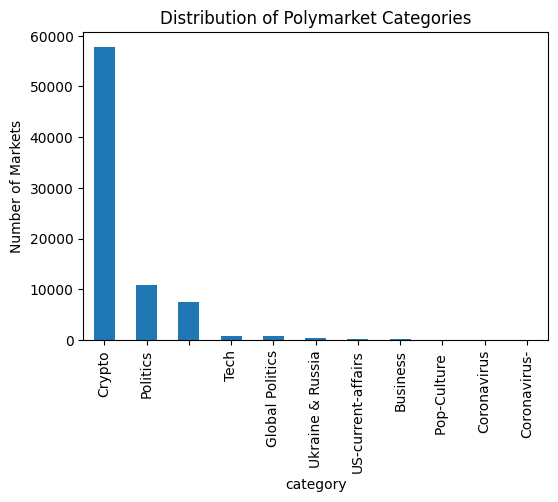

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

markets_df['category'].value_counts().plot(kind='bar')

plt.title("Distribution of Polymarket Categories")
plt.ylabel("Number of Markets")

plt.show()

In [46]:
# Prepare BTC returns
btc_returns = btc_df[['time','date','log_return']].dropna()

btc_returns.head()

,time,date,log_return
562,2010-07-19,2010-07-19,-0.060508
563,2010-07-20,2010-07-20,-0.078019
564,2010-07-21,2010-07-21,0.057928
565,2010-07-22,2010-07-22,-0.303376
566,2010-07-23,2010-07-23,0.035668


In [16]:
# Merge election markets with trades

election_trades = trades_df.merge(
    election_markets[['market_id','question']],
    on='market_id',
    how='inner'
)

election_trades = election_trades.merge(
    btc_df[['date','log_return']],
    on='date',
    how='left'
)

print("Election related trades:", len(election_trades))

election_trades.head()



Election related trades: 2541045


,trade_id,market_id,token_id,timestamp,price,size,side,maker_address,taker_address,date,question,log_return
0,0xabfd5eebac6d4aa43a58624782310d532bd96fb88e8a...,523605,9950717231029230406165947094925029043862287145...,2025-04-07 18:28:15,0.015,14.0,SELL,0x6bb68ddaf47a5296d827f6bf1dfee0bfca9c346f,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,2025-04-07,Will Lee Zeldin be out as Administrator of the...,0.018717
1,0x6621e609bf65d9dcff1ad511edf1c63f30340a04cf49...,523605,9950717231029230406165947094925029043862287145...,2025-04-07 18:28:17,0.015,14.0,SELL,0x6bb68ddaf47a5296d827f6bf1dfee0bfca9c346f,0x6e347bb858a1bb1caf48589f27deb50b6061e45b,2025-04-07,Will Lee Zeldin be out as Administrator of the...,0.018717
2,0xc0344a77412cea81351808d2fcca502e5291734f247b...,523605,9950717231029230406165947094925029043862287145...,2025-04-07 18:28:19,0.015,14.0,SELL,0x6bb68ddaf47a5296d827f6bf1dfee0bfca9c346f,0x2586b27ba2e6b40c986d11ac34e452f7dd623304,2025-04-07,Will Lee Zeldin be out as Administrator of the...,0.018717
3,0xf1b36e0b4ad987ad62dd851b7fab5677782e7e88520c...,523605,9950717231029230406165947094925029043862287145...,2025-04-07 18:28:19,0.015,14.0,SELL,0x6bb68ddaf47a5296d827f6bf1dfee0bfca9c346f,0x97dadc4a3d3a410756edf107b83fb869774dd63d,2025-04-07,Will Lee Zeldin be out as Administrator of the...,0.018717
4,0xd7beea5c9b62b53493aa4f6d0d0d7281d6b712589ec0...,523605,9950717231029230406165947094925029043862287145...,2025-04-07 18:28:29,0.015,14.0,SELL,0x6bb68ddaf47a5296d827f6bf1dfee0bfca9c346f,0x94840aadb29a95c746873c133a1a26202561707d,2025-04-07,Will Lee Zeldin be out as Administrator of the...,0.018717


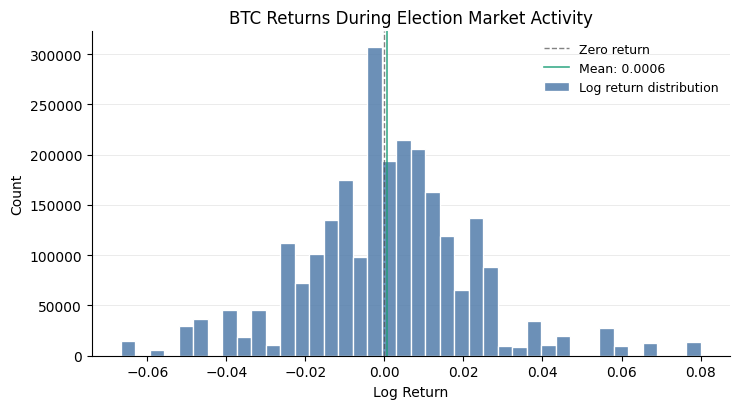

In [31]:
# Clean, minimal distribution of BTC log returns during election-market activity
returns = election_trades['log_return'].dropna()

fig, ax = plt.subplots(figsize=(7.5, 4.2))

sns.histplot(
    returns,
    bins=40,
    color='#4C78A8',
    edgecolor='white',
    alpha=0.82,
    label='Log return distribution',
    ax=ax
)

# Reference lines
ax.axvline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.7, label='Zero return')
mean_val = returns.mean()
ax.axvline(mean_val, color='#1B9E77', lw=1.2, alpha=0.85, label=f"Mean: {mean_val:.4f}")

# Subtle grid and styling
ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_title("BTC Returns During Election Market Activity", fontsize=12)
ax.set_xlabel("Log Return")
ax.set_ylabel("Count")

ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


In [35]:
# Detect country mentioned in question text

country_keywords = {
    'US': 'us|usa|united states|trump|biden|senate|congress',
    'UK': 'uk|britain|london|prime minister',
    'France': 'france|macron',
    'Germany': 'germany',
    'India': 'india|modi',
    'China': 'china|xi'
}

def detect_country(text):

    text = str(text).lower()

    for country, pattern in country_keywords.items():
        if pd.Series(text).str.contains(pattern, regex=True).iloc[0]:
            return country

    return "Other"

election_markets['country'] = election_markets['question'].apply(detect_country)

election_markets['country'].value_counts()

country
US        7348
Other     3485
UK          30
China       28
India       10
France       8
Name: count, dtype: int64

In [47]:
# merge trades with election markets

election_trades_country = trades_df.merge(
    election_markets[['market_id','country']],
    on='market_id',
    how='inner'
)

election_trades_country['timestamp'] = pd.to_datetime(election_trades_country['timestamp'])

election_trades_country = election_trades_country.merge(
    btc_returns,
    on='date',
    how='left'
)


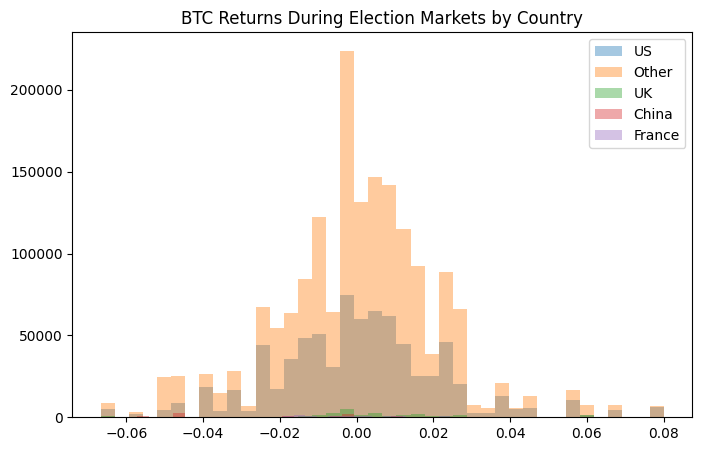

In [48]:
plt.figure(figsize=(8,5))

for country in election_trades_country['country'].unique():

    subset = election_trades_country[
        election_trades_country['country'] == country
    ]

    plt.hist(
        subset['log_return'].dropna(),
        bins=40,
        alpha=0.4,
        label=country
    )

plt.legend()

plt.title("BTC Returns During Election Markets by Country")

plt.show()

In [ ]:
event_windows = []
    
for market_id, group in election_trades_country.groupby('market_id'):

    group = group.sort_values('timestamp')

    if len(group) < 7:
        continue

    window = group.tail(7)

    event_windows.append(window)

event_window_df = pd.concat(event_windows)

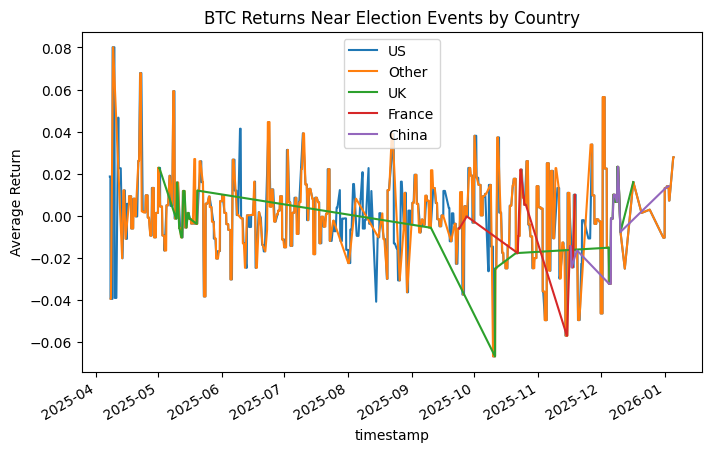

In [51]:
plt.figure(figsize=(8,5))

for country in event_window_df['country'].unique():

    subset = event_window_df[
        event_window_df['country'] == country
    ]

    avg_returns = subset.groupby('timestamp')['log_return'].mean()

    avg_returns.plot(label=country)

plt.legend()

plt.title("BTC Returns Near Election Events by Country")

plt.ylabel("Average Return")

plt.show()

In [ ]:
event_windows = []

for market_id, group in election_trades_country.groupby('market_id'):

    group = group.sort_values('timestamp')

    # Only keep market with enough trade history
    if len(group) < 7:
        continue

    window = group.tail(7).copy()

    # Create event time
    window['event_time'] = range(-6, 1)

    event_windows.append(window)

event_window_df = pd.concat(event_windows)

avg_returns = (
    event_window_df
    .groupby(['country','event_time'])['log_return']
    .mean()
    .reset_index()
)

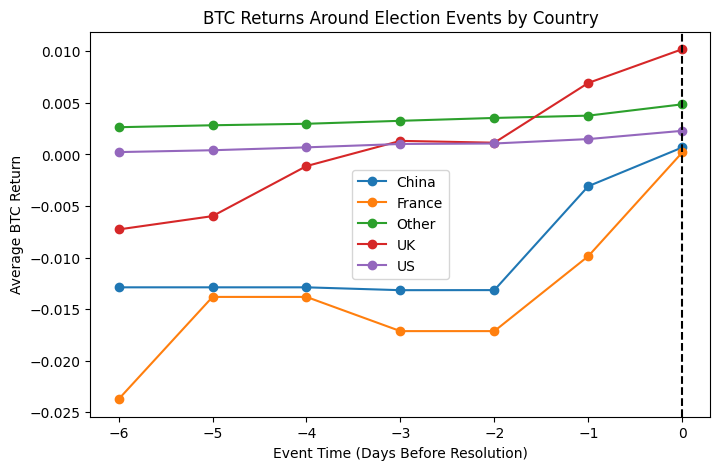

In [58]:
plt.figure(figsize=(8,5))

for country in avg_returns['country'].unique():

    subset = avg_returns[
        avg_returns['country'] == country
    ]

    plt.plot(
        subset['event_time'],
        subset['log_return'],
        marker='o',
        label=country
    )

plt.axvline(0, linestyle='--', color='black')

plt.xlabel("Event Time (Days Before Resolution)")
plt.ylabel("Average BTC Return")

plt.title("BTC Returns Around Election Events by Country")

plt.legend()

plt.show()

In [54]:
election_odds = odds_history_df.merge(
    election_markets[['market_id','country']],
    on='market_id',
    how='inner'
)

election_odds = election_odds.merge(
    btc_returns,
    on='date',
    how='left'
)

d:\Anaconda\envs\tf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


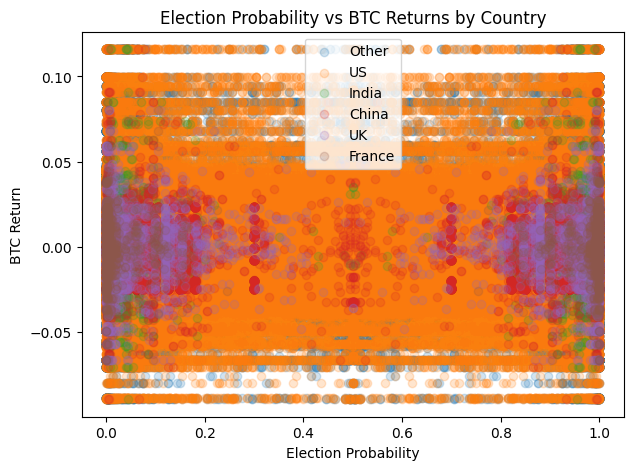

In [61]:
plt.figure(figsize=(7,5))

for country in election_odds['country'].unique():

    subset = election_odds[
        election_odds['country'] == country
    ]

    plt.scatter(
        subset['price'],
        subset['log_return'],
        alpha=0.2,
        label=country
    )
    

plt.legend()

plt.xlabel("Election Probability")

plt.ylabel("BTC Return")

plt.title("Election Probability vs BTC Returns by Country")

plt.show()

***Part 3***

In [52]:
geo_markets = markets_df[
    markets_df['category'].isin([
        'Ukraine & Russia',
        'Global Politics'
    ])
].copy()

print("Geopolitical markets:", len(geo_markets))

Geopolitical markets: 987


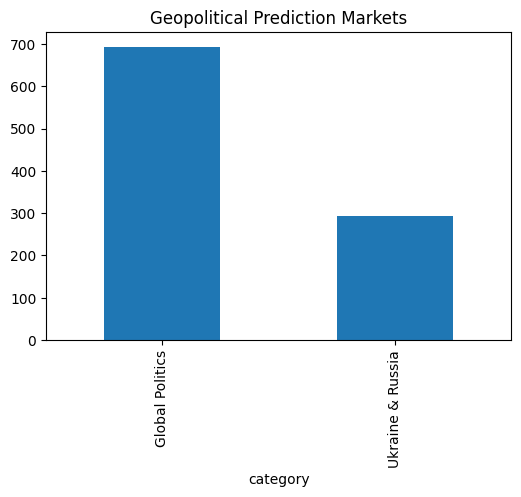

In [53]:
geo_markets['category'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Geopolitical Prediction Markets")

plt.show()

In [ ]:
geo_trades = trades_df.merge(
    geo_markets[['market_id','question','category']],
    on='market_id',
    how='inner'
)

# Convert timestamp
geo_trades["timestamp"] = pd.to_datetime(geo_trades["timestamp"])

# Extract date
geo_trades["date"] = geo_trades["timestamp"].dt.date

# BTC date
btc_df["date"] = btc_df["time"].dt.date

# Merge
geo_trades = geo_trades.merge(
    btc_df[["date","log_return"]],
    on="date",
    how="left"
)

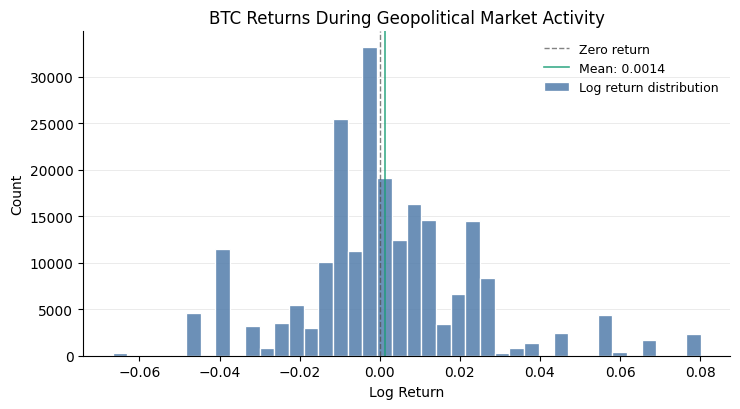

In [32]:
# Clean, minimal distribution of BTC log returns during geopolitical-market activity
geo_returns = geo_trades['log_return'].dropna()

fig, ax = plt.subplots(figsize=(7.5, 4.2))

sns.histplot(
    geo_returns,
    bins=40,
    color='#4C78A8',
    edgecolor='white',
    alpha=0.82,
    label='Log return distribution',
    ax=ax
)

# Reference lines
ax.axvline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.7, label='Zero return')
mean_val = geo_returns.mean()
ax.axvline(mean_val, color='#1B9E77', lw=1.2, alpha=0.85, label=f"Mean: {mean_val:.4f}")

# Subtle grid and styling
ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_title("BTC Returns During Geopolitical Market Activity", fontsize=12)
ax.set_xlabel("Log Return")
ax.set_ylabel("Count")

ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


In [22]:
event_windows = []

for market_id, group in geo_trades.groupby('market_id'):

    group = group.sort_values('timestamp')

    if len(group) < 5:
        continue

    window = group.tail(5)

    event_windows.append(window)

event_window_df = pd.concat(event_windows)

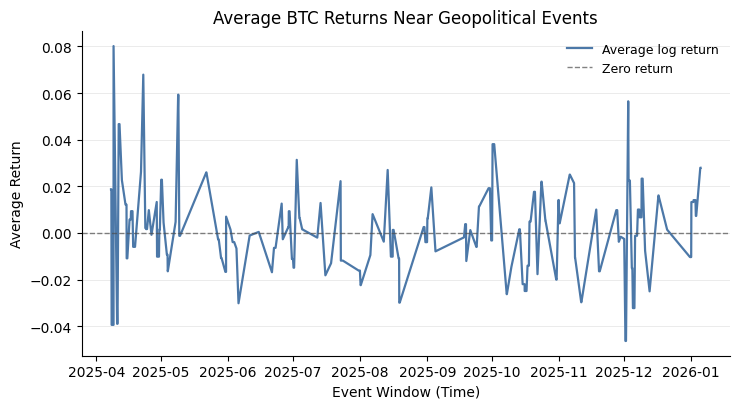

In [33]:
# Clean, minimal time series of average returns around geopolitical events
avg_returns = event_window_df.groupby('timestamp')['log_return'].mean()

fig, ax = plt.subplots(figsize=(7.5, 4.2))

ax.plot(
    avg_returns.index,
    avg_returns.values,
    color='#4C78A8',
    lw=1.6,
    label='Average log return'
)

# Reference lines
ax.axhline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.7, label='Zero return')

# Subtle grid and styling
ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_title("Average BTC Returns Near Geopolitical Events", fontsize=12)
ax.set_xlabel("Event Window (Time)")
ax.set_ylabel("Average Return")

ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


In [24]:
# Merge odds history with geopolitical markets

geo_odds = odds_history_df.merge(
    geo_markets[['market_id','question','category']],
    on='market_id',
    how='inner'
)

print("geo odds rows:", len(geo_odds))
geo_odds.head()

geo_odds["date"] = geo_odds["timestamp"].dt.date

geo_odds = geo_odds.merge(
    btc_df[["date","log_return"]],
    on="date",
    how="left"
)

geo_odds["uncertainty"] = abs(geo_odds["price"] - 0.5)

geo odds rows: 56453


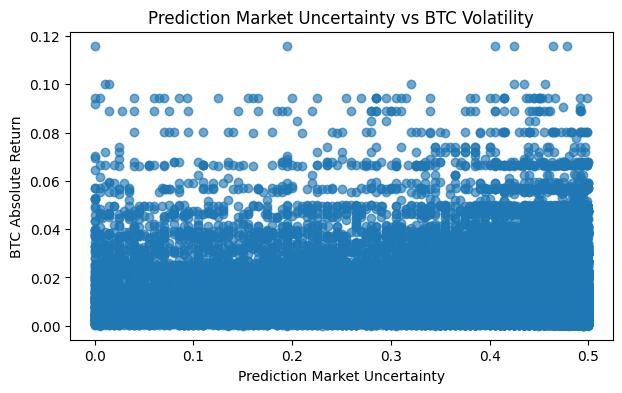

In [25]:
plt.figure(figsize=(7,4))

plt.scatter(
    geo_odds["uncertainty"],
    abs(geo_odds["log_return"]),
    alpha=0.4
)

plt.xlabel("Prediction Market Uncertainty")
plt.ylabel("BTC Absolute Return")

plt.title("Prediction Market Uncertainty vs BTC Volatility")

plt.show()

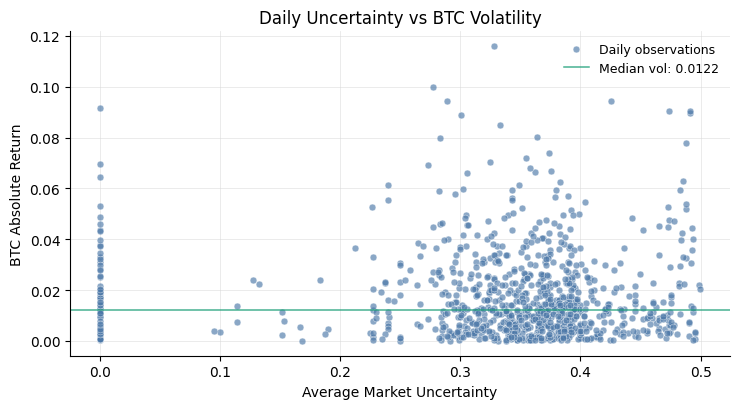

In [34]:
# Clean, minimal scatter: daily uncertainty vs BTC volatility
daily_geo = geo_odds.groupby("date").agg({
    "uncertainty": "mean",
    "log_return": "mean"
}).reset_index()

fig, ax = plt.subplots(figsize=(7.5, 4.2))

ax.scatter(
    daily_geo["uncertainty"],
    daily_geo["log_return"].abs(),
    s=24,
    color="#4C78A8",
    alpha=0.65,
    edgecolor="white",
    linewidth=0.4,
    label="Daily observations"
)

# Optional reference line at median volatility
med_vol = daily_geo["log_return"].abs().median()
ax.axhline(med_vol, color="#1B9E77", lw=1.1, alpha=0.8, label=f"Median vol: {med_vol:.4f}")

# Subtle grid and styling
ax.grid(color="#D9D9D9", lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_title("Daily Uncertainty vs BTC Volatility", fontsize=12)
ax.set_xlabel("Average Market Uncertainty")
ax.set_ylabel("BTC Absolute Return")

ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()
